# ABABA trial: extended schedule comparison

Runs an **A1 → B1 → A2 → B2 → A3** (ABABA) schedule for **one participant**, with two-module RNN (dim_hidden=25), comparing **shared** vs **task_routed** input, **three communication sparsities** (0.3, 0.7, 1), and **three rule conditions** (same, near, far). Analysis: accuracy, loss, and PCA geometry after every phase.

## 1. Setup and paths

In [8]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
from torch.utils.data import DataLoader
from torch import nn

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.data.basic_funcs import get_datasets, get_clockwise_order
from a1b2.models.ffn import CreateParticipantDataset, batch_to_torch, ordered_sweep
from a1b2.training.schedule import train_participant_schedule, _split_hiddens_by_module
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.transfer_interference import (
    load_participant_data,
    generate_geometry_df,
    setup_task_parameters,
    prepare_pca_single_task,
    compute_principal_angle,
)

data_folder = project_root / "data"
print("Project root:", project_root)

Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular


## 2. Data extraction

Load trial_df, pick one participant (e.g. first "same" condition), build geometry df for same/near/far B, then build datasets and loaders for A1, B_same, B_near, B_far, A2.

In [9]:
df = load_participant_data(str(data_folder))
task_parameters = setup_task_parameters()

same_participants = df[df["condition"] == "same"]["participant"].unique()
participant_id = same_participants[0] if len(same_participants) > 0 else df["participant"].iloc[0]
print("Using participant:", participant_id)

geometry_df = generate_geometry_df(df, participant_id, near_rule=np.pi / 6, far_rule=np.pi)

dataset_A1, dataset_B_same, dataset_A2, raw_inputs_same, raw_labels_same = get_datasets(
    geometry_df, "geom_sub_same", task_parameters
)
_, dataset_B_near, _, _, _ = get_datasets(geometry_df, "geom_sub_near", task_parameters)
_, dataset_B_far, _, _, _ = get_datasets(geometry_df, "geom_sub_far", task_parameters)

A_inputs = raw_inputs_same[0]
B_inputs = raw_inputs_same[1]
A_labels_feat1 = raw_labels_same[0, 0:2].T
B_labels_feat1 = raw_labels_same[1, 0:2].T
ordered_indices_A = get_clockwise_order(A_labels_feat1)
ordered_indices_B = get_clockwise_order(B_labels_feat1)
ordered_inputs = np.concatenate(
    (A_inputs[ordered_indices_A], B_inputs[ordered_indices_B]), axis=0
)

batch_size = 1
shuffle = False
trainloader_A1 = DataLoader(
    CreateParticipantDataset(dataset_A1), batch_size=batch_size, shuffle=shuffle
)
trainloader_A2 = DataLoader(
    CreateParticipantDataset(dataset_A2), batch_size=batch_size, shuffle=shuffle
)
trainloader_B_same = DataLoader(
    CreateParticipantDataset(dataset_B_same), batch_size=batch_size, shuffle=shuffle
)
trainloader_B_near = DataLoader(
    CreateParticipantDataset(dataset_B_near), batch_size=batch_size, shuffle=shuffle
)
trainloader_B_far = DataLoader(
    CreateParticipantDataset(dataset_B_far), batch_size=batch_size, shuffle=shuffle
)
print("Loaders and ordered_inputs ready.")

Using participant: study1_same_sub9
Loaders and ordered_inputs ready.


## 3. Task parameters

In [10]:
dim_input = task_parameters["nStim_perTask"] * 2
dim_output = 4
n_epochs = 50
lr = 0.01
gamma = 0.01
do_test = 1
nb_steps = 1
n_train_trials = n_epochs * dim_input * 10
n_phase_ababa = 5
n_stim = ordered_inputs.shape[0]
print("dim_input:", dim_input, "n_epochs:", n_epochs, "n_phase_ababa:", n_phase_ababa)

dim_input: 12 n_epochs: 50 n_phase_ababa: 5


## 4. ABABA schedule runner

Runs five phases: A1, B, A2, B, A2 with do_update (1, 1, 2, 1, 2). Returns results dict with per-phase accuracy, losses, and post-phase hiddens/predictions.

In [11]:
def run_ababa_schedule(
    network,
    trainloader_A1,
    trainloader_B,
    trainloader_A2,
    ordered_inputs,
    n_epochs,
    do_test,
    dim_input,
    dim_hidden,
    dim_output,
    n_train_trials,
    n_stim,
    forward_kwargs_from_batch=None,
    nb_steps=1,
    rnn_extra=None,
):
    device = next(network.parameters()).device
    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(network.parameters(), lr=0.01)

    phases = [
        (0, trainloader_A1, 1),
        (1, trainloader_B, 1),
        (2, trainloader_A2, 2),
        (3, trainloader_B, 1),
        (4, trainloader_A2, 2),
    ]

    results = {
        "accuracy": np.full((5, n_train_trials), np.nan, dtype=np.float32),
        "losses": np.full((5, n_train_trials), np.nan, dtype=np.float32),
        "predictions": np.full((5, n_train_trials, dim_output), np.nan, dtype=np.float32),
        "hiddens": np.full((5, n_train_trials, dim_hidden), np.nan, dtype=np.float32),
    }
    for i in range(5):
        results[f"preds_post_phase_{i}"] = np.full((n_stim, dim_output), np.nan, dtype=np.float32)
        results[f"hiddens_post_phase_{i}"] = np.full((n_stim, dim_hidden), np.nan, dtype=np.float32)

    for phase, loader, do_update in tqdm(phases, desc="Phases", leave=False):
        out = train_participant_schedule(
            network,
            loader,
            n_epochs,
            loss_function,
            optimizer,
            do_update,
            do_test,
            forward_kwargs_from_batch=forward_kwargs_from_batch,
            nb_steps=nb_steps,
            device=device,
        )
        idx, inp, lbl, prb, test, loss, acc, pred, hid, emb, rd = out
        n = min(len(idx), n_train_trials)
        results["accuracy"][phase, :n] = acc[:n]
        results["losses"][phase, :n] = loss[:n]
        results["predictions"][phase, :n, :] = pred[:n]
        results["hiddens"][phase, :n, :] = hid[:n]

        sweep_result = ordered_sweep(
            network, ordered_inputs, nb_steps=nb_steps, return_trajectory=False
        )
        post_preds, post_hiddens = sweep_result[0], sweep_result[1]
        results[f"preds_post_phase_{phase}"] = post_preds
        results[f"hiddens_post_phase_{phase}"] = post_hiddens

    return results

## 5. Training loop (18 runs)

Grid: 2 (shared, task_routed) × 3 (sparsity 0.3, 0.7, 1) × 3 (same, near, far). One network per configuration.

In [12]:
from a1b2.models.two_module_rnn import TwoModuleRNNWrapper

routings = ["shared", "task_routed"]
sparsities = [0.3, 0.7, 1.0]
rules = ["same", "near", "far"]
loaders_by_rule = {
    "same": trainloader_B_same,
    "near": trainloader_B_near,
    "far": trainloader_B_far,
}

hidden_size = 25
n_modules = 2
dim_hidden_rnn = n_modules * hidden_size
rnn_extra = {"n_modules": n_modules, "hidden_size": hidden_size}

all_results = []
from itertools import product
configs = list(product(routings, sparsities, rules))
for routing, sparsity, rule in tqdm(configs, desc="Runs"):
    condition = {
        "dim_hidden": hidden_size,
        "sparsity": sparsity,
        "input_routing": routing,
        "common_input": False,
        "common_readout": True,
        "cell_type": "RNN",
    }
    network = TwoModuleRNNWrapper(
        input_size=dim_input,
        output_size=dim_output,
        hidden_size=condition["dim_hidden"],
        n_modules=n_modules,
        sparsity=condition["sparsity"],
        common_input=condition["common_input"],
        common_readout=condition["common_readout"],
        cell_type=condition["cell_type"],
        input_routing=condition["input_routing"],
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    network = network.to(device)

    forward_kwargs_from_batch = None
    if routing == "task_routed":
        forward_kwargs_from_batch = lambda data: {
            "feature_probe": batch_to_torch(data["feature_probe"]).to(device)
        }

    trainloader_B = loaders_by_rule[rule]
    res = run_ababa_schedule(
        network,
        trainloader_A1,
        trainloader_B,
        trainloader_A2,
        ordered_inputs,
        n_epochs,
        do_test,
        dim_input,
        dim_hidden_rnn,
        dim_output,
        n_train_trials,
        n_stim,
        forward_kwargs_from_batch=forward_kwargs_from_batch,
        nb_steps=nb_steps,
        rnn_extra=rnn_extra,
    )
    res["routing"] = routing
    res["sparsity"] = sparsity
    res["rule"] = rule
    all_results.append(res)

print("Runs completed:", len(all_results))

Runs: 100%|██████████| 18/18 [22:30<00:00, 75.01s/it]

Runs completed: 18


## 6. Analysis: accuracy, loss, PCA geometry

Aggregate accuracy and loss per phase; compute PCA and principal angles; compare across task similarity, sparsity, and routing.

In [13]:
phase_names = ["A1", "B1", "A2", "B2", "A3"]

acc_rows = []
loss_rows = []
for res in all_results:
    for phase in range(5):
        acc = res["accuracy"][phase]
        acc_valid = acc[~np.isnan(acc)]
        loss = res["losses"][phase]
        loss_valid = loss[~np.isnan(loss)]
        acc_rows.append({
            "routing": res["routing"],
            "sparsity": res["sparsity"],
            "rule": res["rule"],
            "phase": phase_names[phase],
            "phase_idx": phase,
            "mean_accuracy": np.nanmean(acc_valid) if len(acc_valid) else np.nan,
        })
        loss_rows.append({
            "routing": res["routing"],
            "sparsity": res["sparsity"],
            "rule": res["rule"],
            "phase": phase_names[phase],
            "phase_idx": phase,
            "mean_loss": np.nanmean(loss_valid) if len(loss_valid) else np.nan,
        })

acc_df = pd.DataFrame(acc_rows)
loss_df = pd.DataFrame(loss_rows)

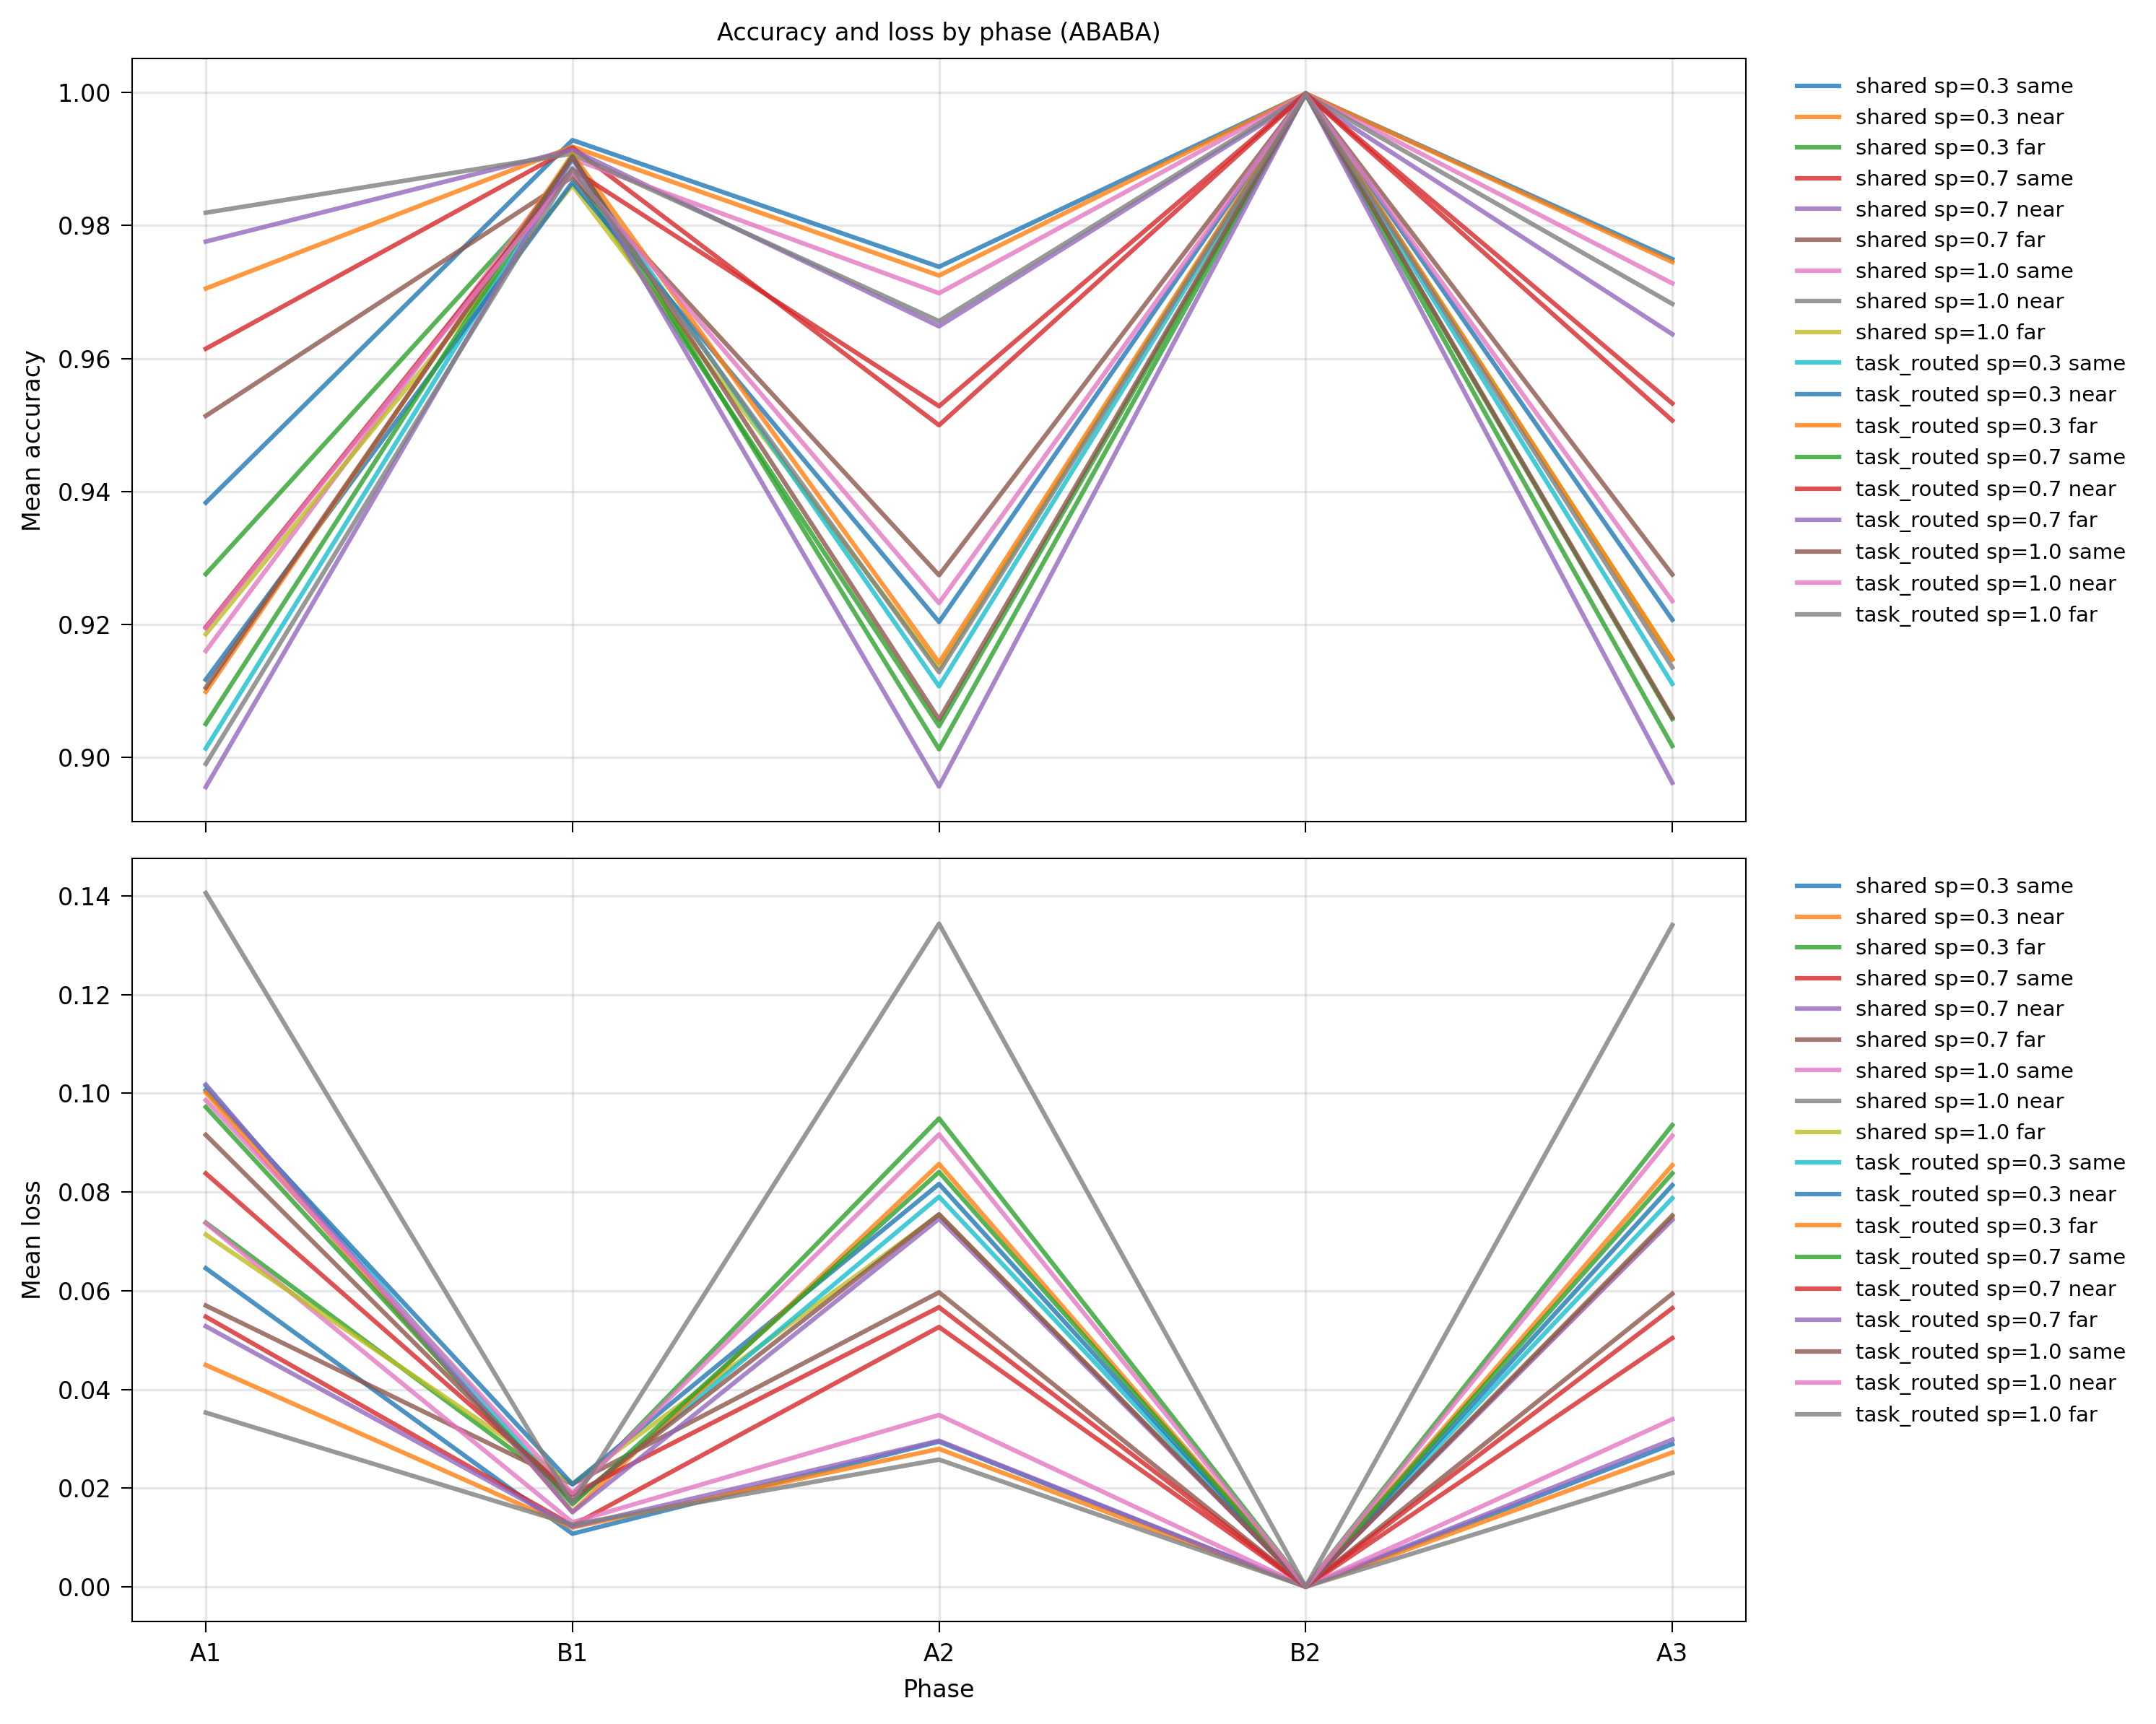

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for ax, df, ycol, ylabel in zip(
    axes,
    [acc_df, loss_df],
    ["mean_accuracy", "mean_loss"],
    ["Mean accuracy", "Mean loss"],
):
    for (routing, sparsity), grp in df.groupby(["routing", "sparsity"]):
        for rule in rules:
            sub = grp[grp["rule"] == rule]
            sub = sub.sort_values("phase_idx")
            label = f"{routing} sp={sparsity} {rule}"
            ax.plot(sub["phase_idx"], sub[ycol], label=label, alpha=0.8)
    ax.set_ylabel(ylabel)
    ax.legend(bbox_to_anchor=(1.02, 1), fontsize=7)
    ax.grid(True, alpha=0.3)
axes[0].set_title("Accuracy and loss by phase (ABABA)")
axes[1].set_xlabel("Phase")
plt.setp(axes[1].get_xticklabels(), rotation=0)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(phase_names)
plt.tight_layout()
plt.show()

In [15]:
n_stim_A = task_parameters["nStim_perTask"]
principal_angle_rows = []
for res in all_results:
    for phase in range(5):
        hids = res[f"hiddens_post_phase_{phase}"]
        if np.any(np.isnan(hids)):
            continue
        A_hids = hids[:n_stim_A]
        B_hids = hids[n_stim_A:]
        ang_deg, _ = compute_principal_angle(A_hids, B_hids, n_components=2)
        principal_angle_rows.append({
            "routing": res["routing"],
            "sparsity": res["sparsity"],
            "rule": res["rule"],
            "phase": phase_names[phase],
            "phase_idx": phase,
            "principal_angle_deg": ang_deg,
        })

angle_df = pd.DataFrame(principal_angle_rows)

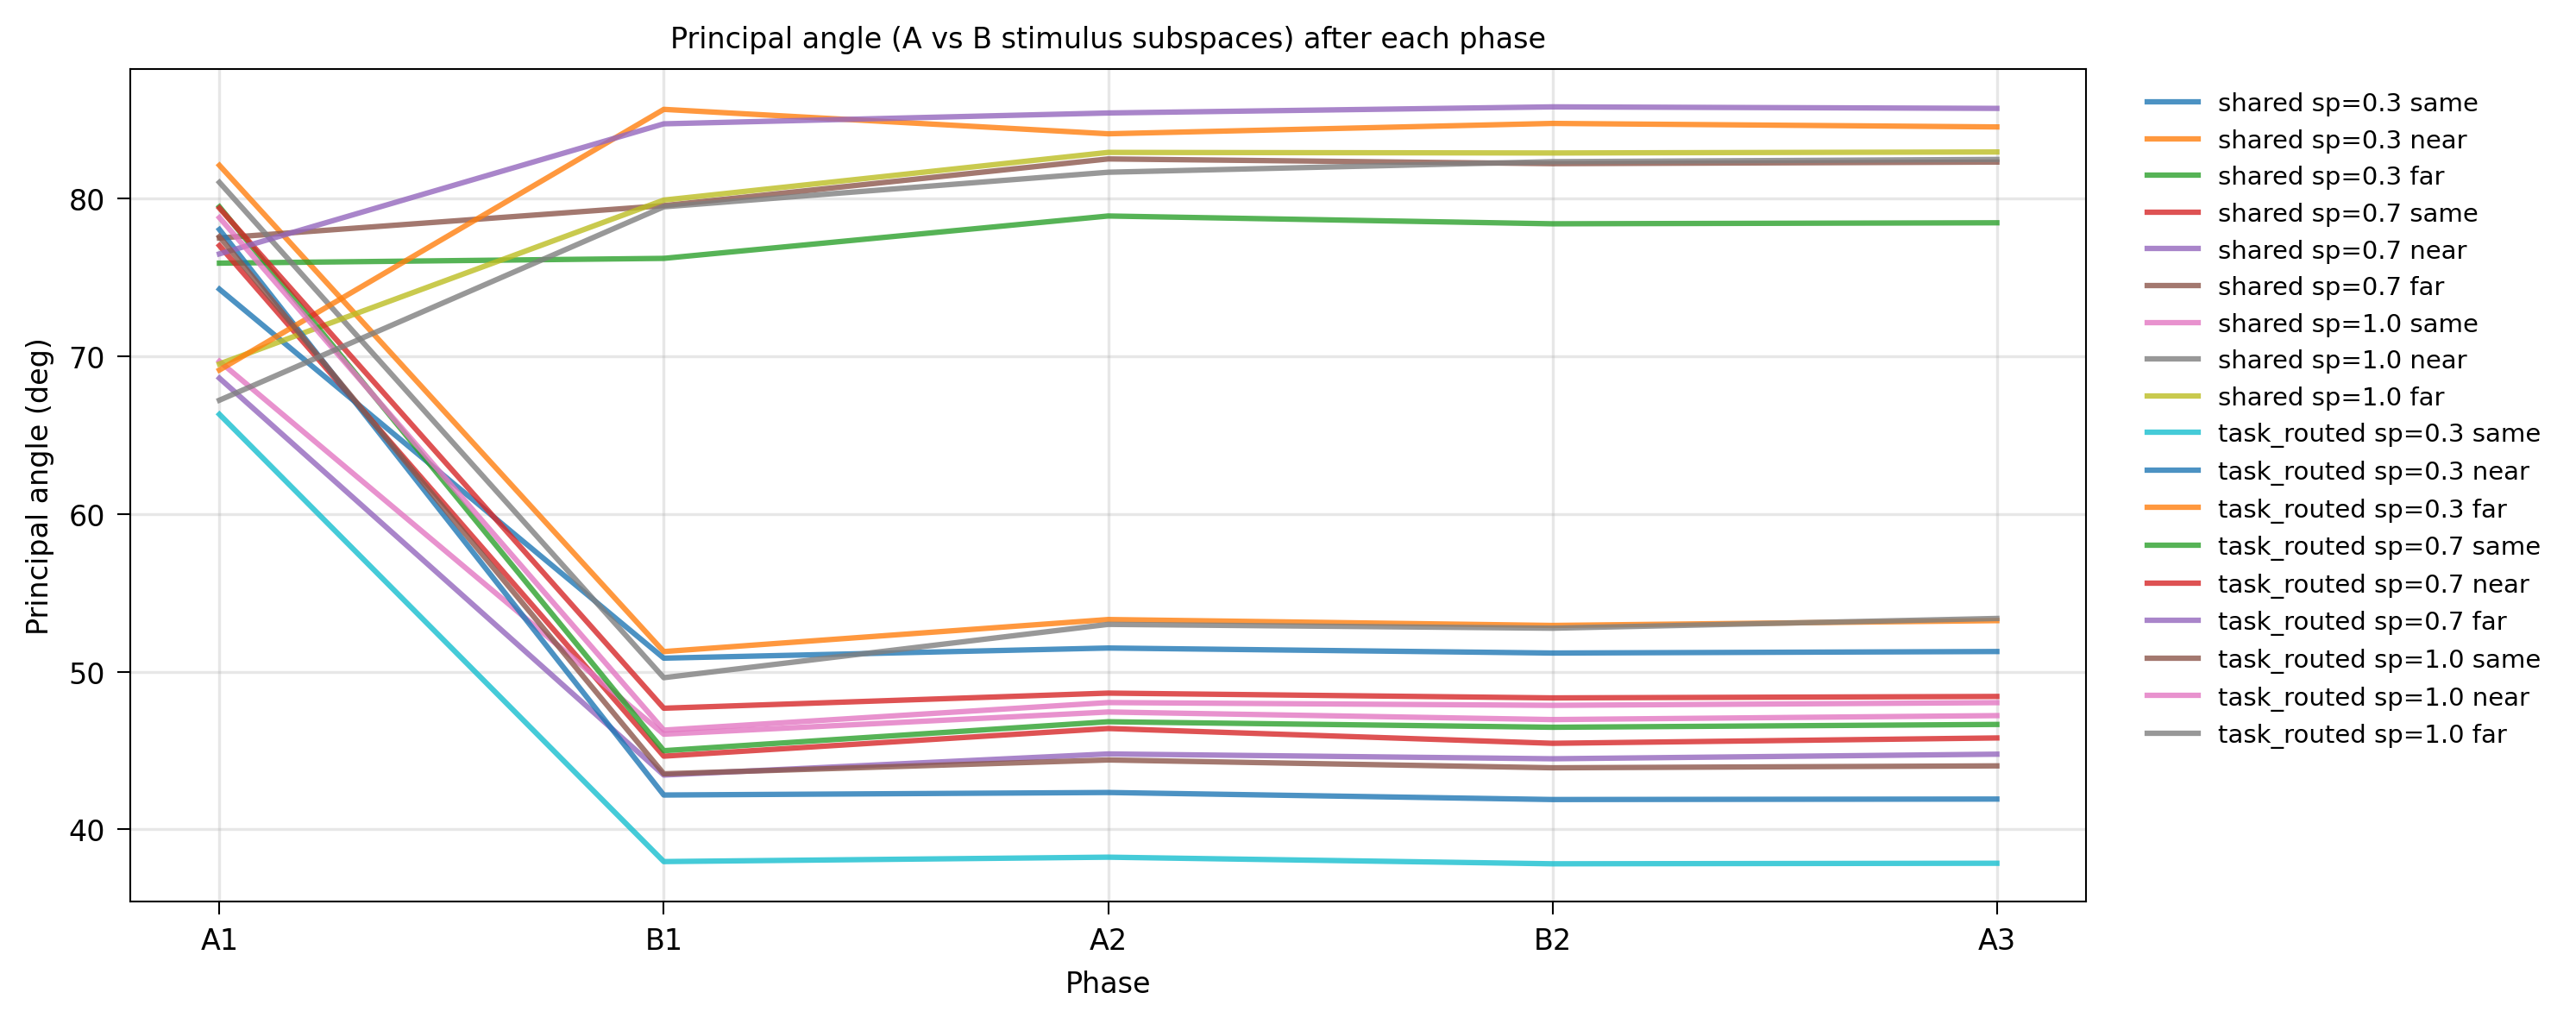

In [16]:
plt.figure(figsize=(10, 4))
for (routing, sparsity), grp in angle_df.groupby(["routing", "sparsity"]):
    for rule in rules:
        sub = grp[grp["rule"] == rule].sort_values("phase_idx")
        plt.plot(
            sub["phase_idx"],
            sub["principal_angle_deg"],
            label=f"{routing} sp={sparsity} {rule}",
            alpha=0.8,
        )
plt.xlabel("Phase")
plt.ylabel("Principal angle (deg)")
plt.xticks(range(5), phase_names)
plt.legend(bbox_to_anchor=(1.02, 1), fontsize=7)
plt.title("Principal angle (A vs B stimulus subspaces) after each phase")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

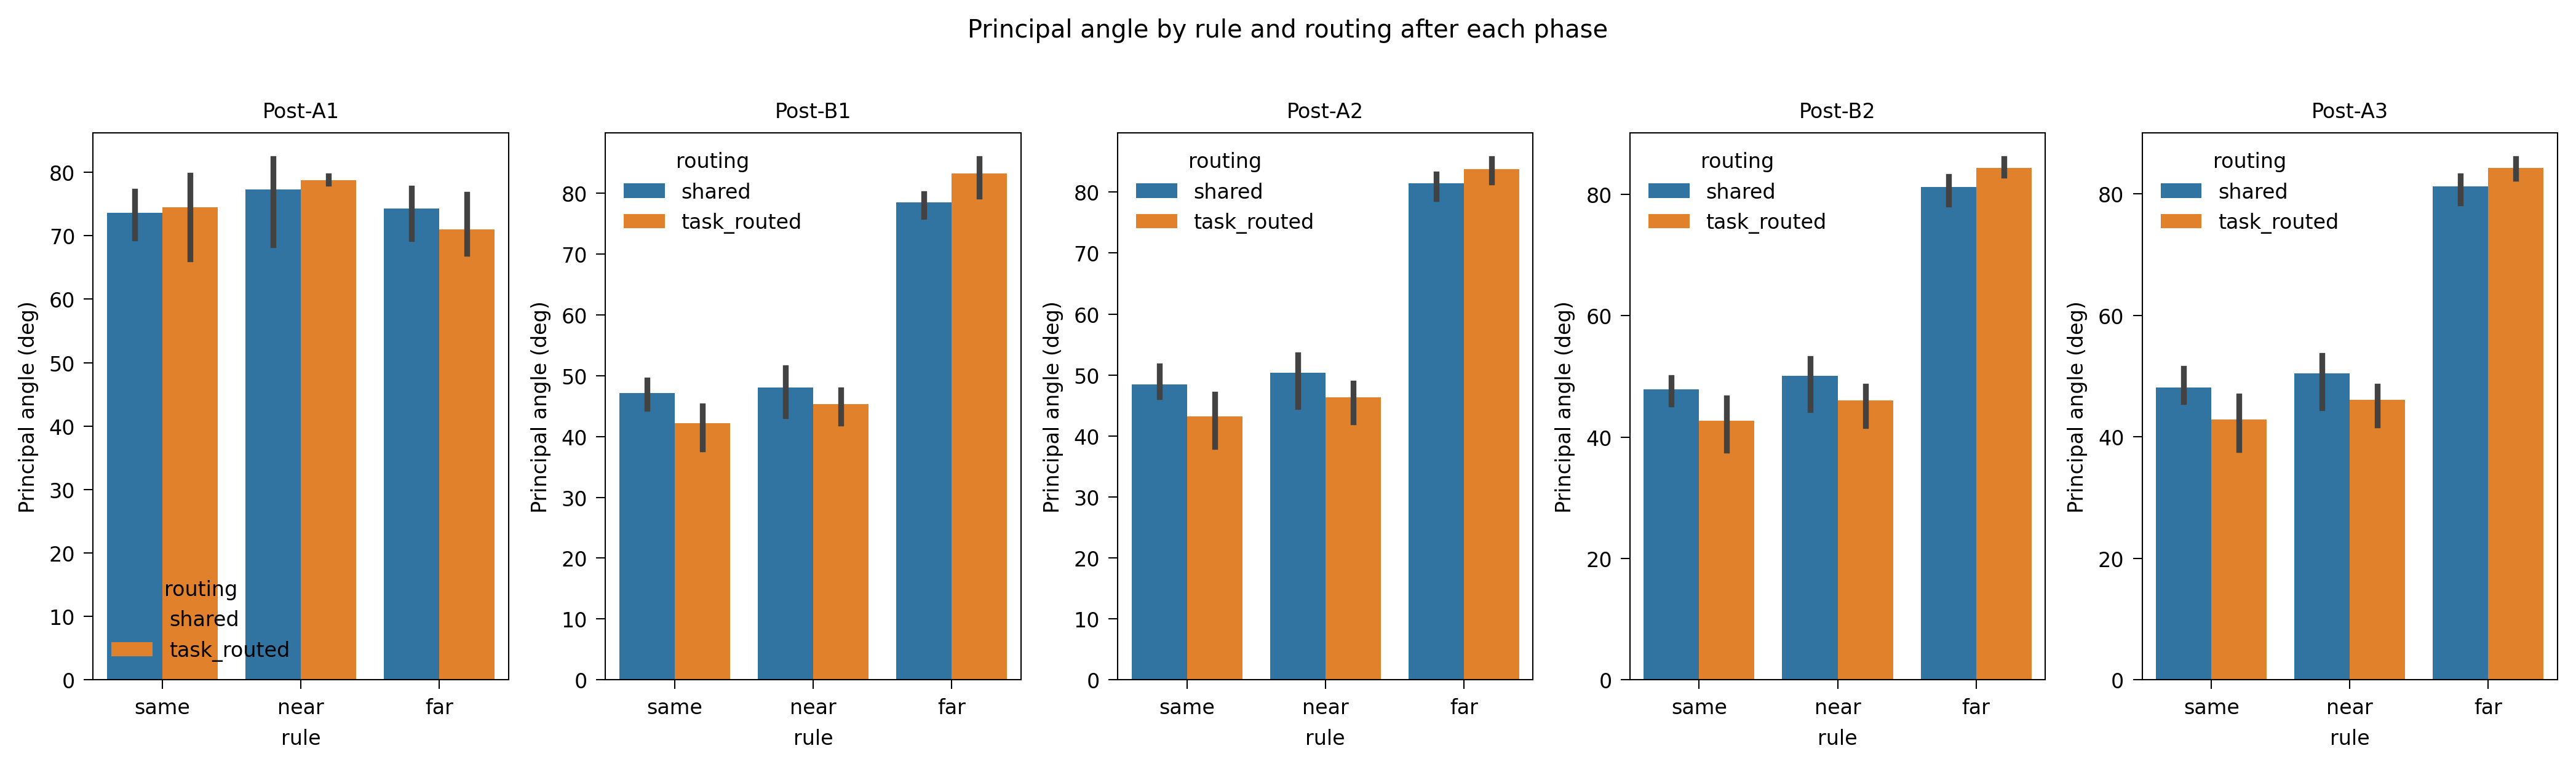

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for idx, phase in enumerate(range(5)):
    ax = axes[idx]
    sub = angle_df[angle_df["phase_idx"] == phase]
    if sub.empty:
        ax.set_visible(False)
        continue
    sns.barplot(
        data=sub,
        x="rule",
        y="principal_angle_deg",
        hue="routing",
        hue_order=["shared", "task_routed"],
        ax=ax,
    )
    ax.set_title(f"Post-{phase_names[phase]}")
    ax.set_ylabel("Principal angle (deg)")
plt.suptitle("Principal angle by rule and routing after each phase", y=1.02)
plt.tight_layout()
plt.show()

## Detailed loss curves (Holton style)

Per-configuration training loss over time (all 5 phases concatenated). Vertical lines mark phase boundaries (A1|B1|A2|B2|A3). Same style as nb_all_runs_comparison: raw loss with optional rolling smooth, one panel per (routing × sparsity × rule).

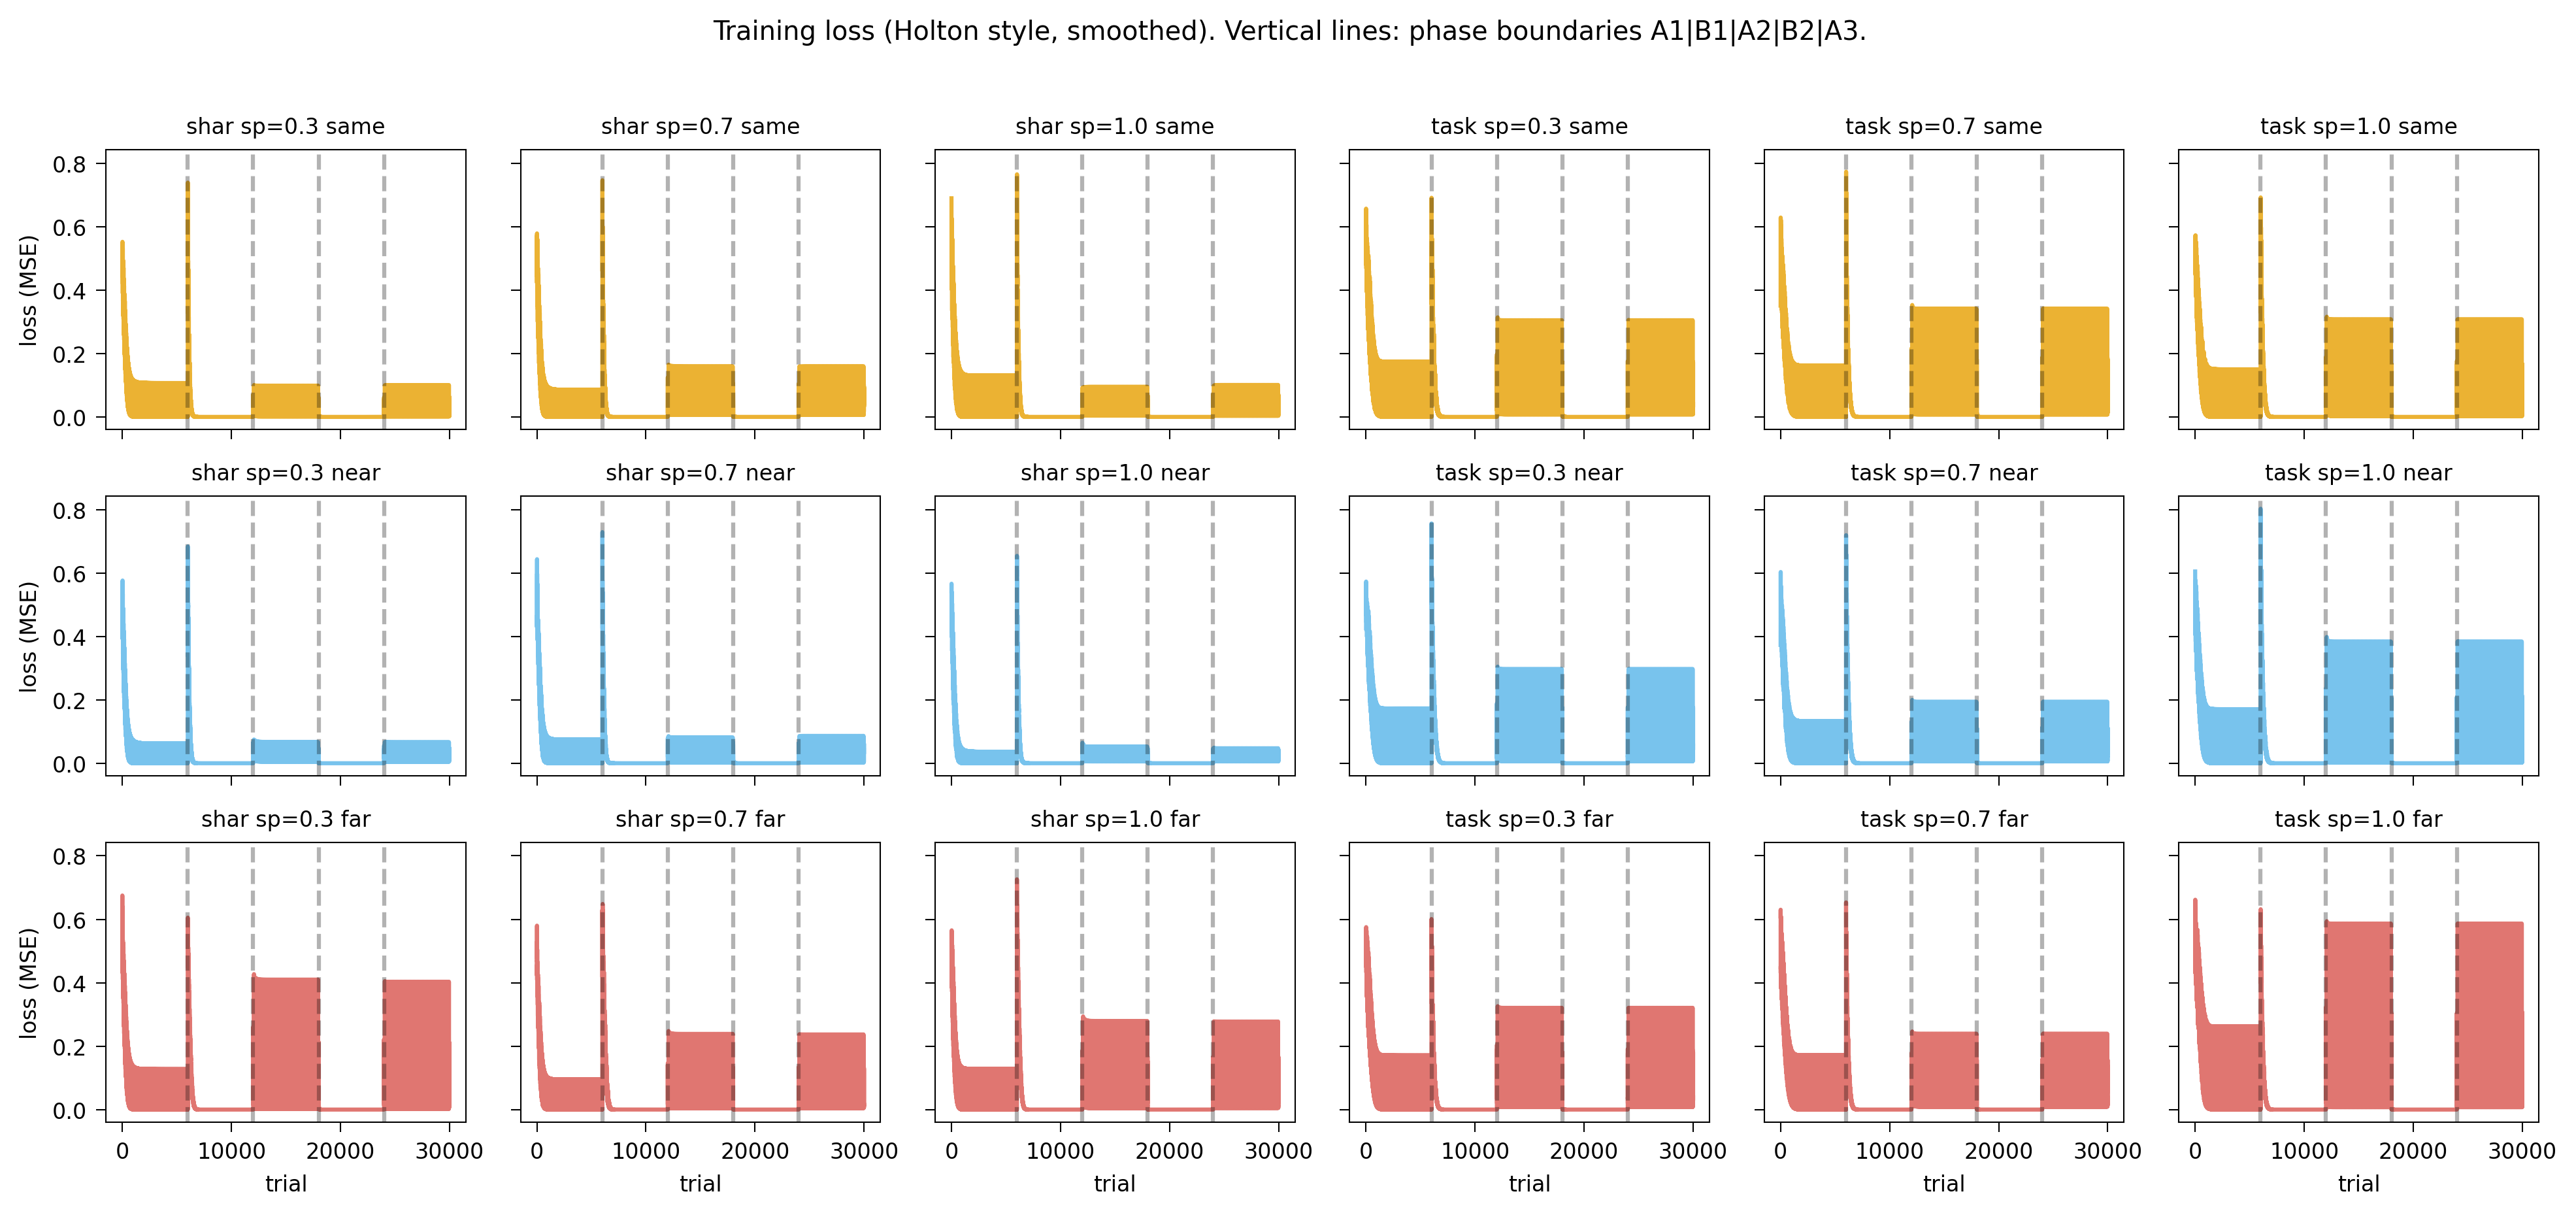

In [18]:
from a1b2.utils.figure_settings import schedule_colours, condition_order

SUBPLOT_W = 2.2
SUBPLOT_H = 2.0
smooth_window = 5

fig, axes = plt.subplots(3, 6, figsize=(SUBPLOT_W * 6, SUBPLOT_H * 3), sharex=True, sharey=True)
for res in all_results:
    r = rules.index(res["rule"])
    c = routings.index(res["routing"]) * 3 + sparsities.index(res["sparsity"])
    ax = axes[r, c]
    # Concatenate loss over all 5 phases (Holton-style: full schedule)
    losses_5 = res["losses"]  # (5, n_trials)
    n_per_phase = losses_5.shape[1]
    mean_loss = losses_5.ravel()
    steps = np.arange(len(mean_loss))
    smooth_mean = pd.Series(mean_loss).rolling(window=smooth_window, center=True, min_periods=1).mean().to_numpy()
    color = schedule_colours[condition_order.index(res["rule"])]
    ax.plot(steps, smooth_mean, color=color, alpha=0.8, linewidth=1.5)
    # Phase boundaries (A1|B1|A2|B2|A3 → 4 vertical lines)
    for b in [n_per_phase, 2 * n_per_phase, 3 * n_per_phase, 4 * n_per_phase]:
        ax.axvline(b, color="k", linestyle="--", alpha=0.3)
    ax.set_title(f"{res['routing'][:4]} sp={res['sparsity']} {res['rule']}", fontsize=8)
    if c == 0:
        ax.set_ylabel("loss (MSE)")
    if r == 2:
        ax.set_xlabel("trial")
fig.suptitle("Training loss (Holton style, smoothed). Vertical lines: phase boundaries A1|B1|A2|B2|A3.", y=1.02)
plt.tight_layout()
plt.show()

## PCA 2D representation overlap (post-phase hiddens)

For each post-phase (A1, B1, A2, B2, A3), 2D PCA of hidden states with A vs B stimuli (first 6 = Task A, last 6 = Task B). Overlap in PCA space reflects how separated the two task representations are.

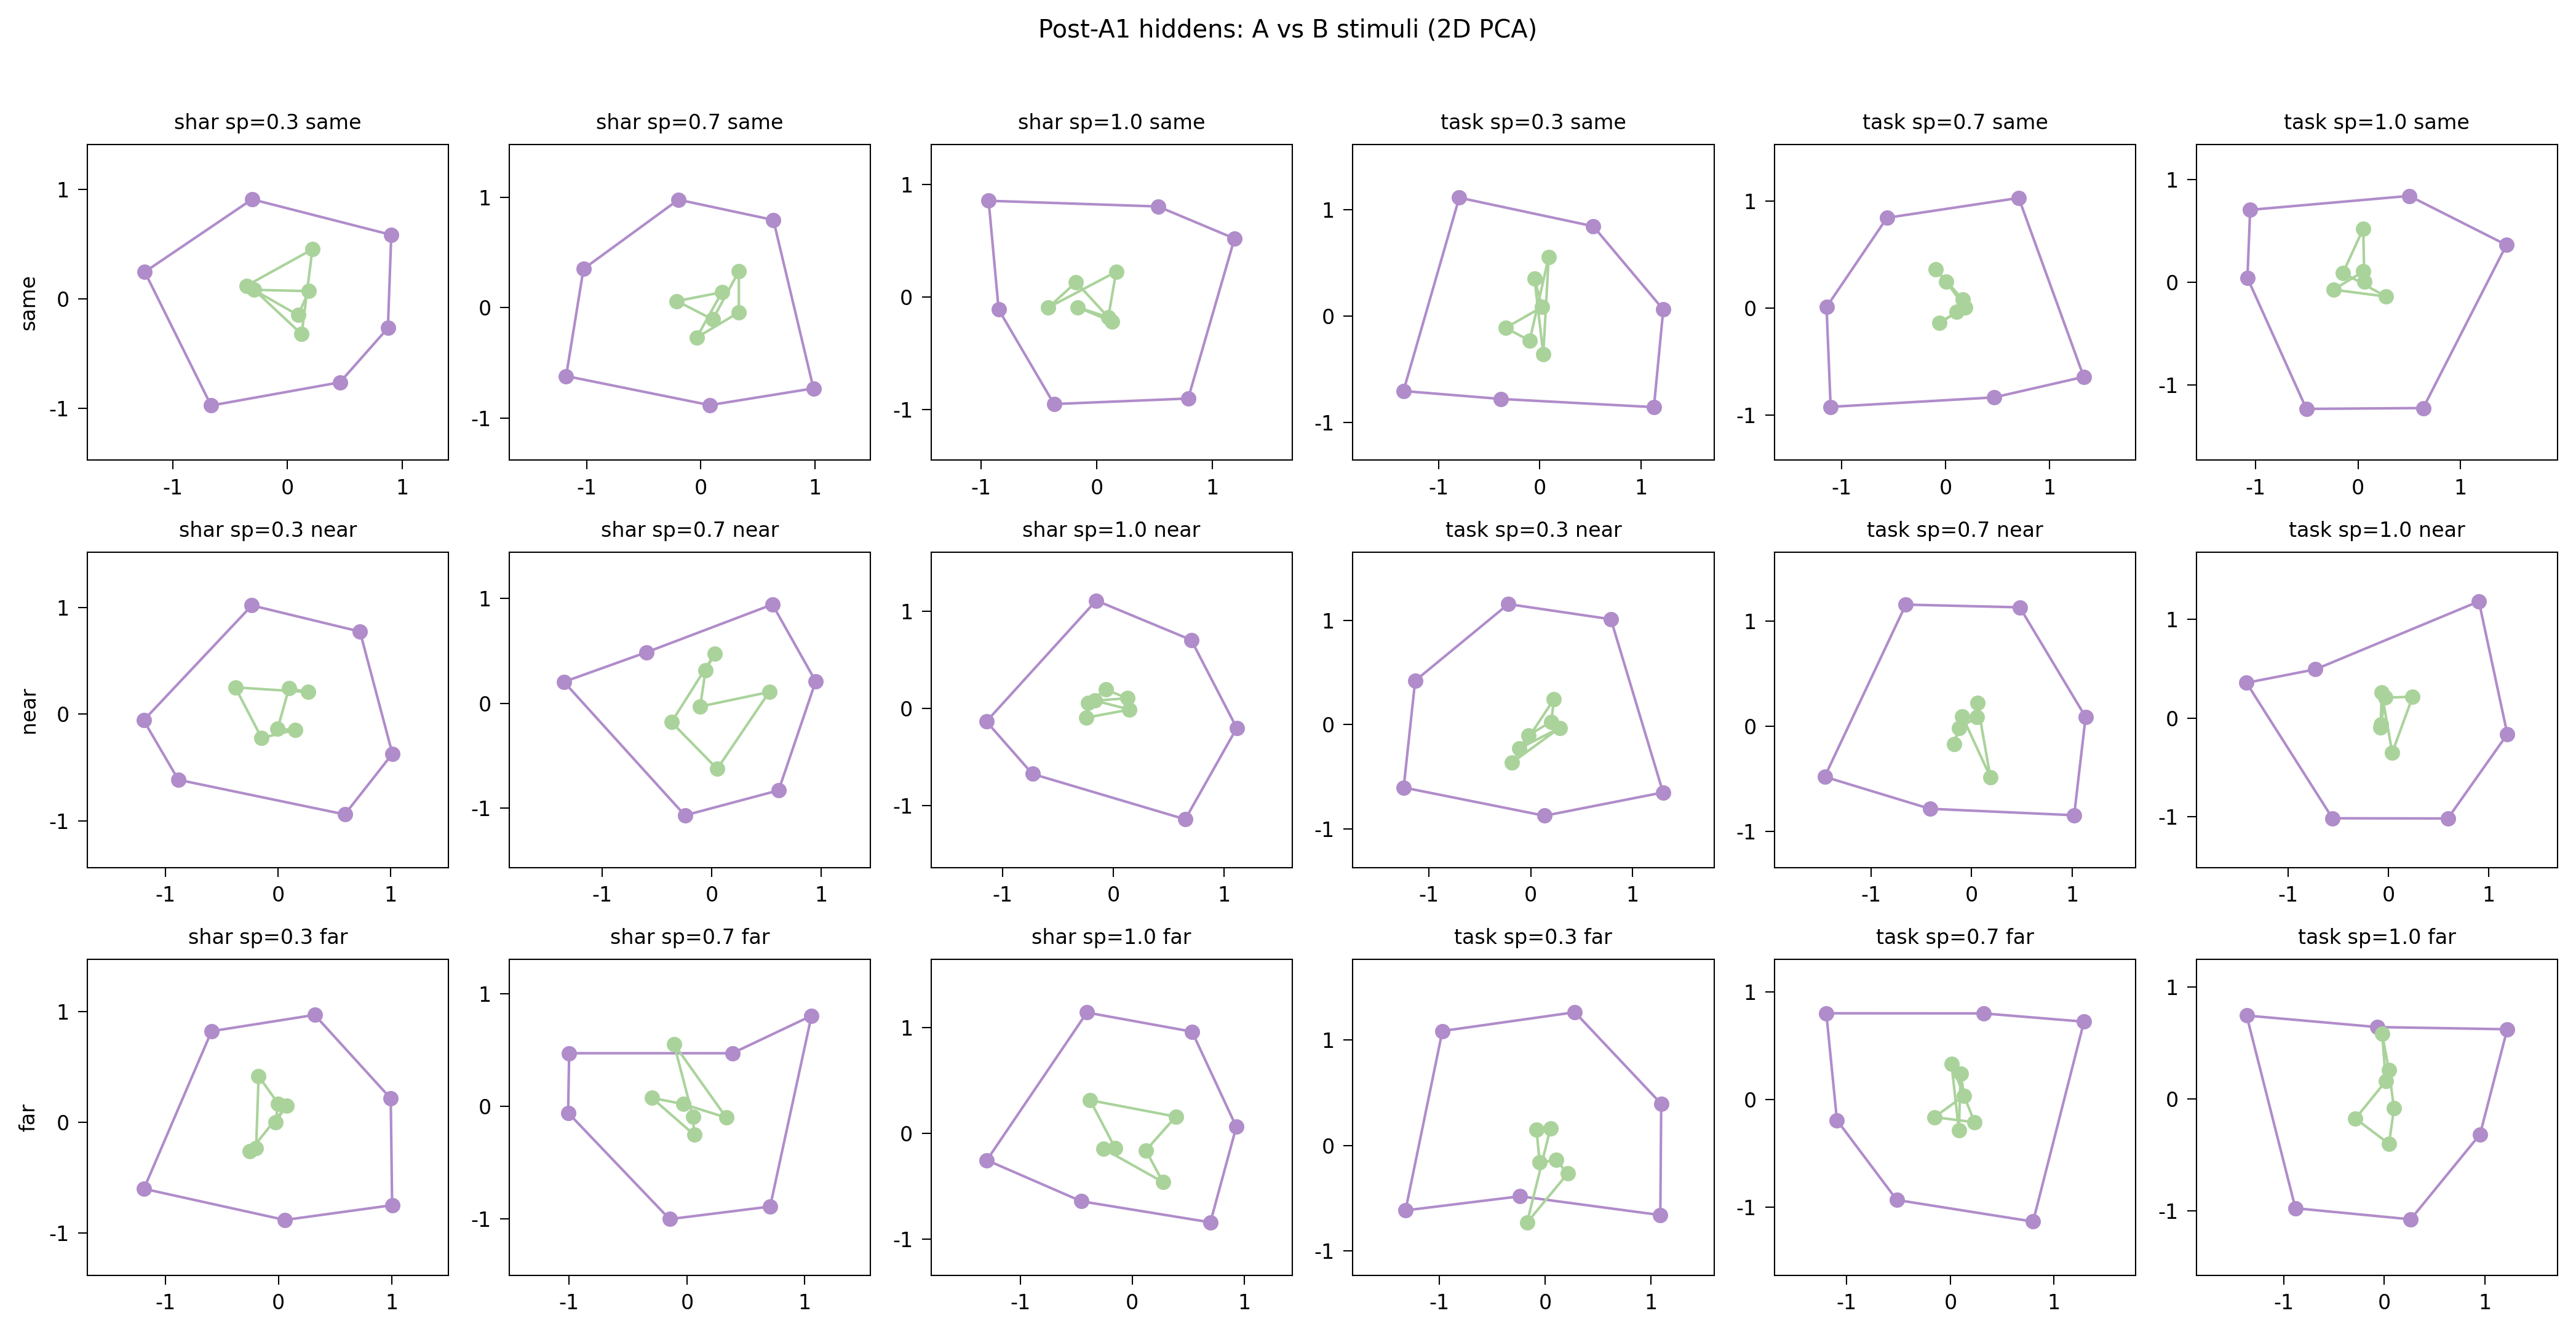

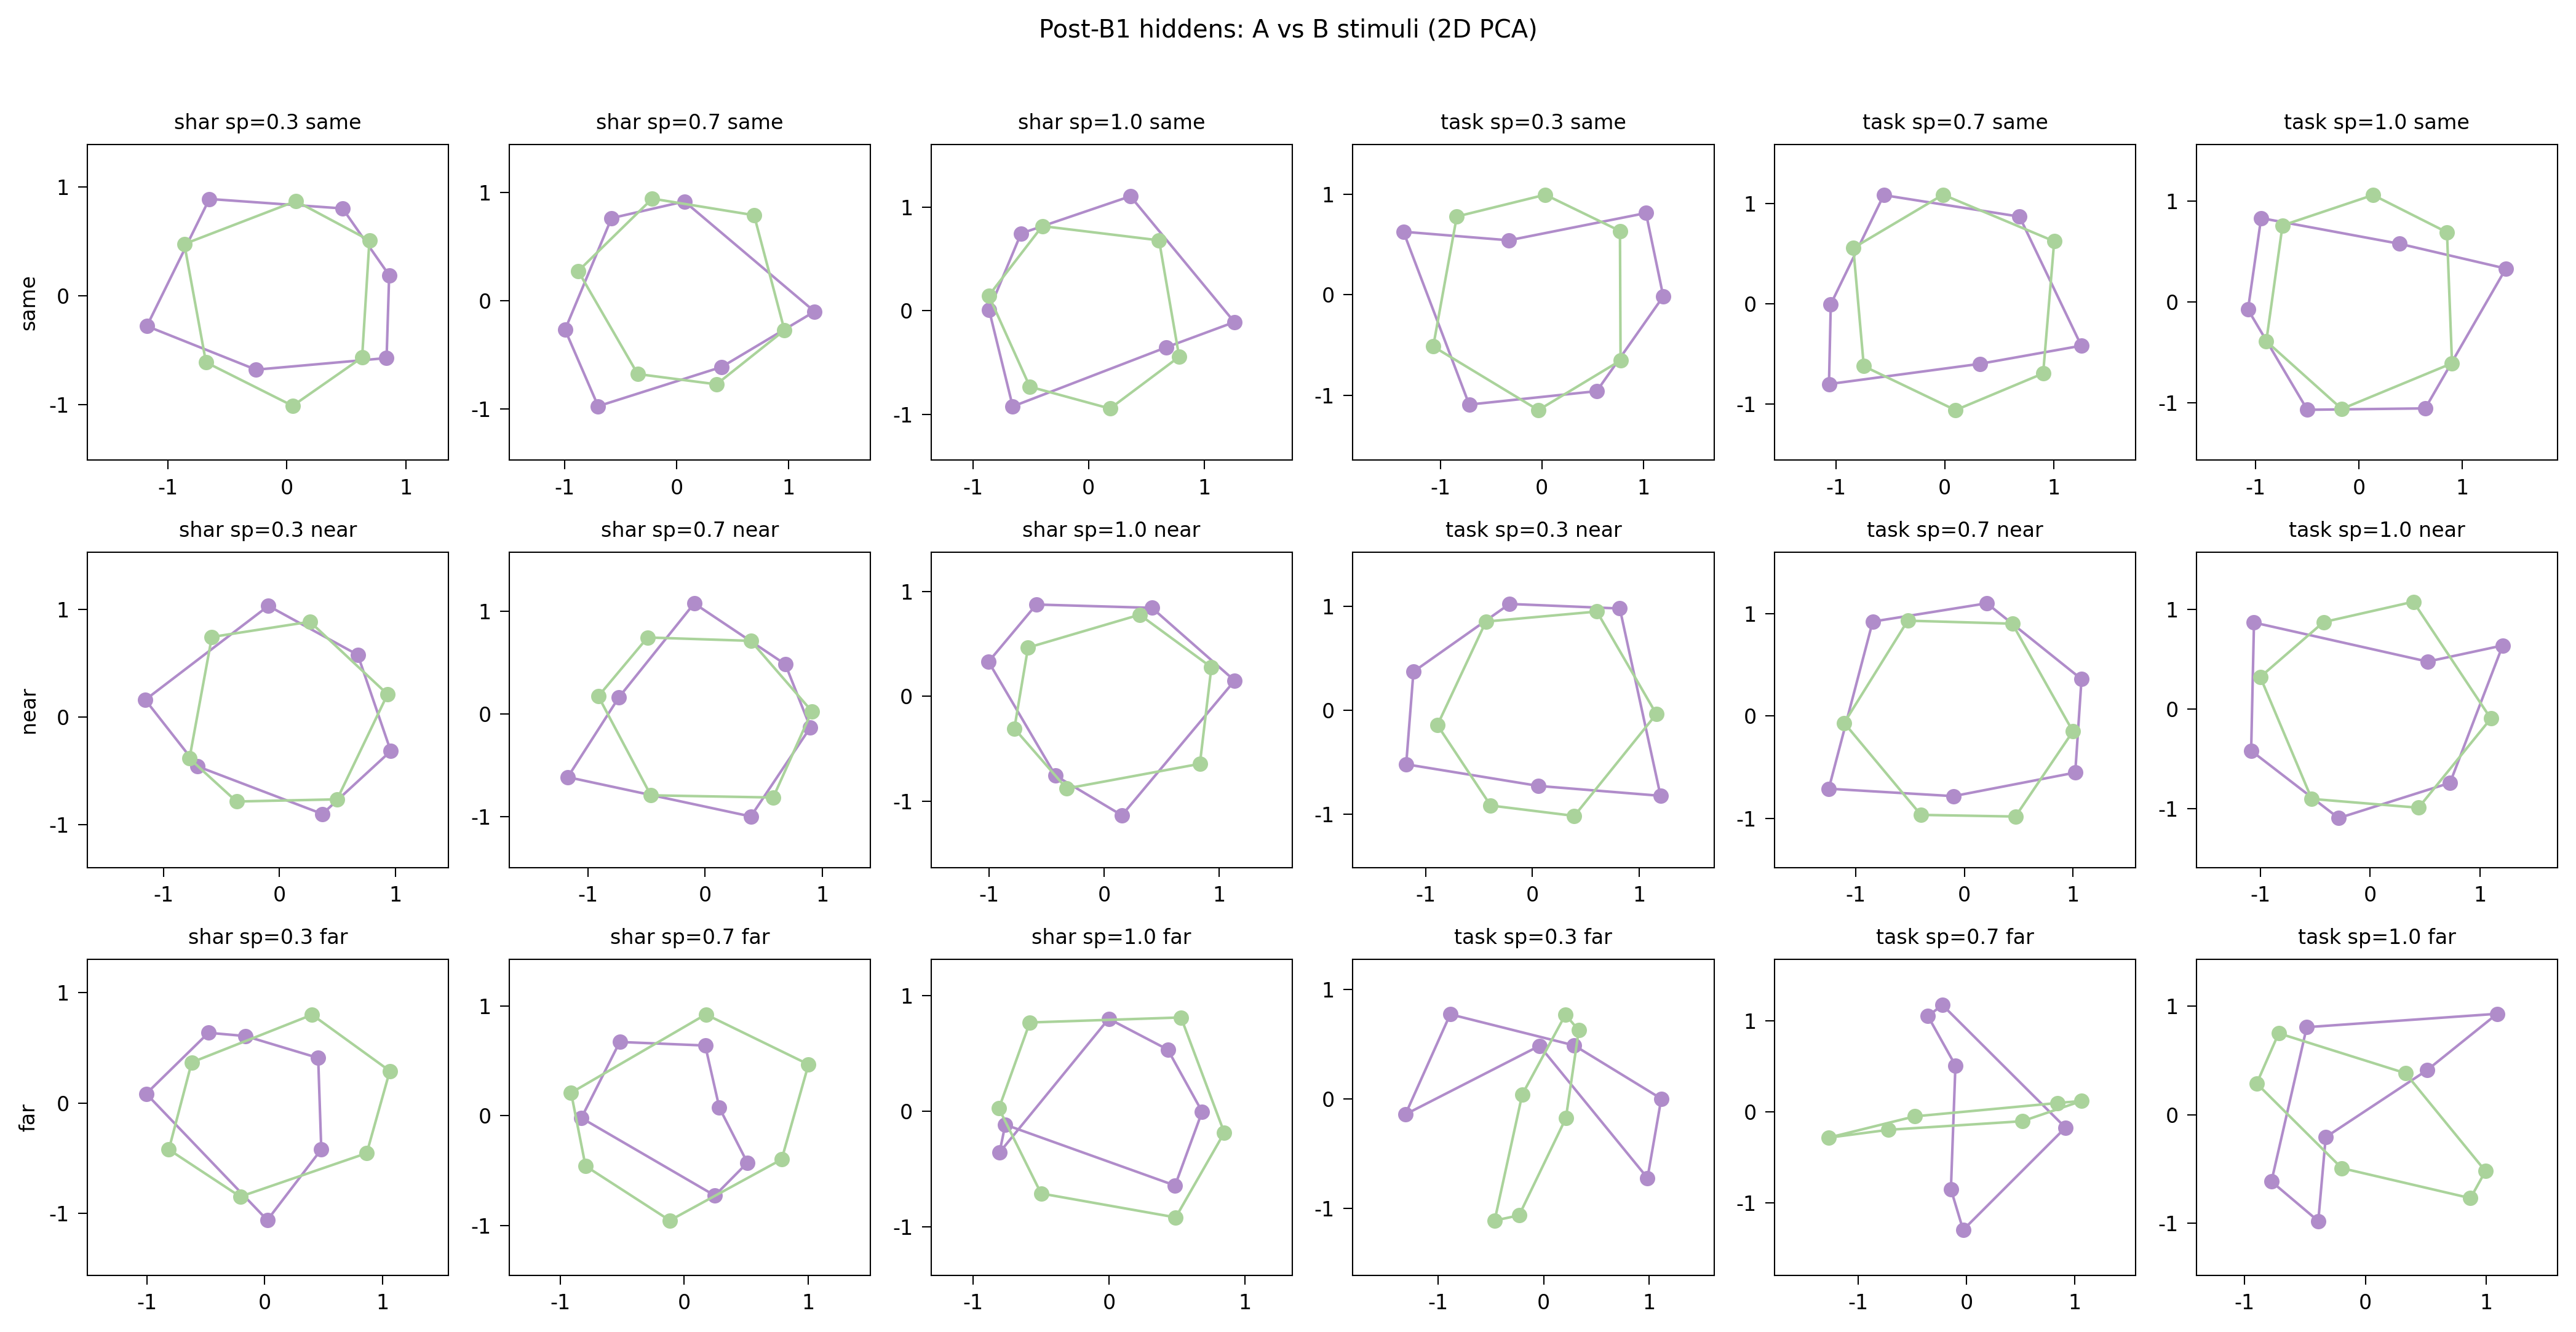

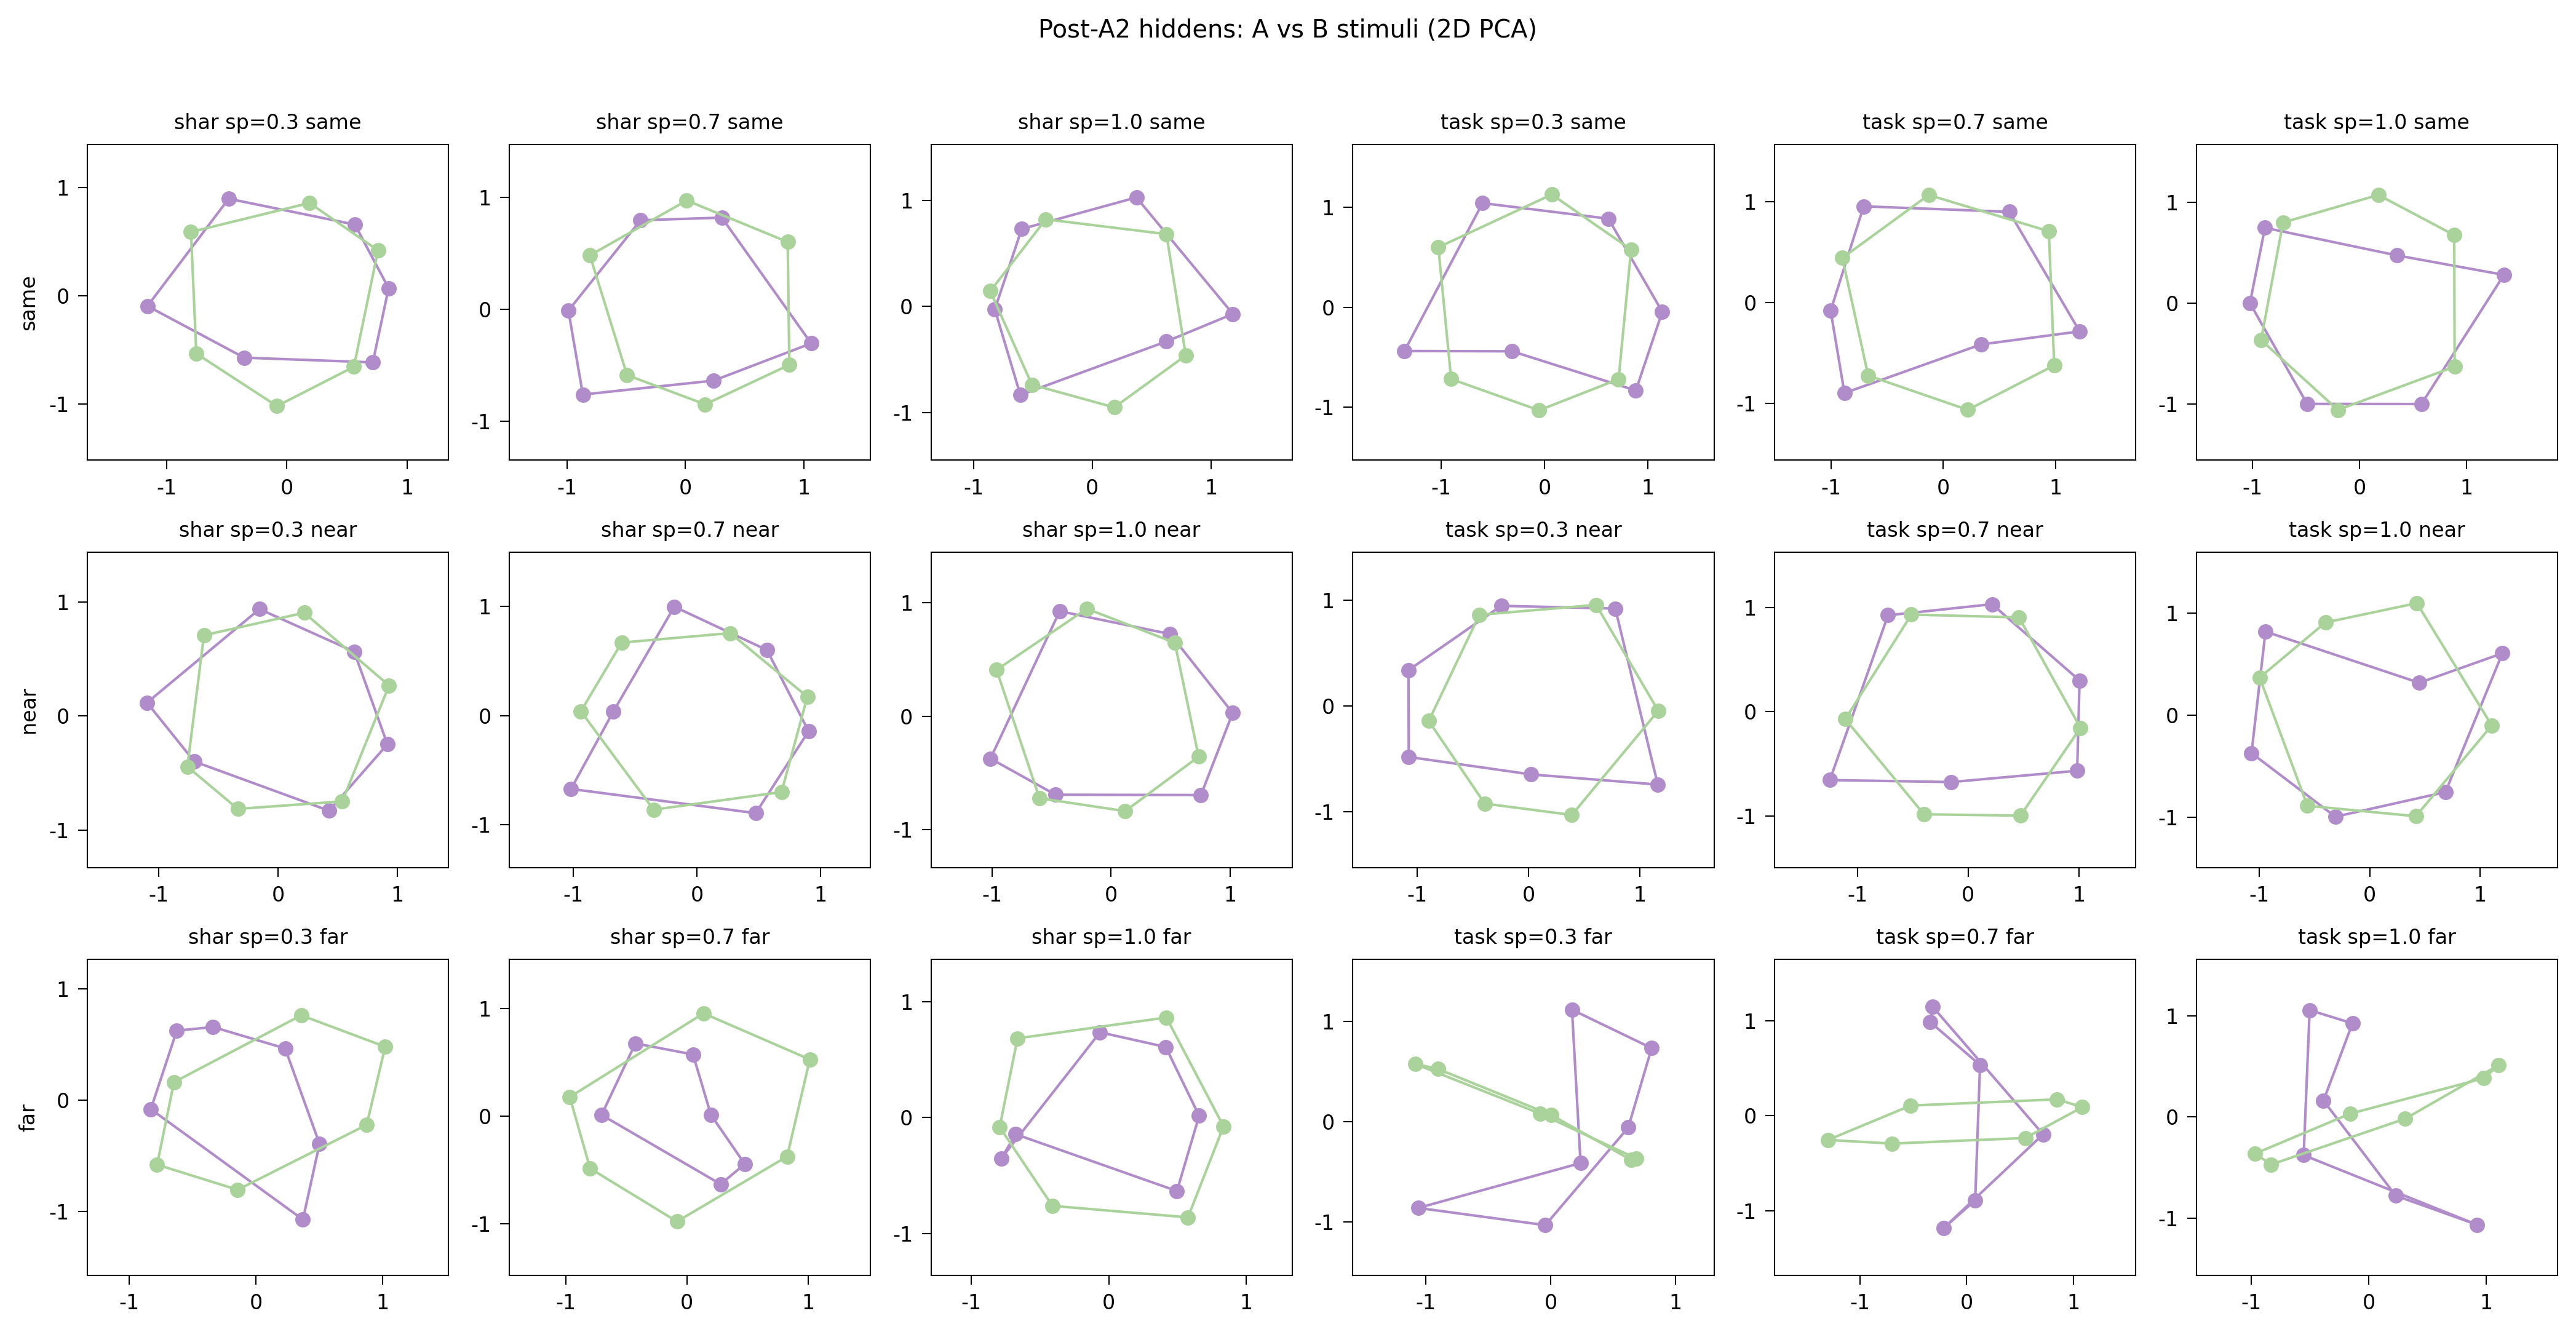

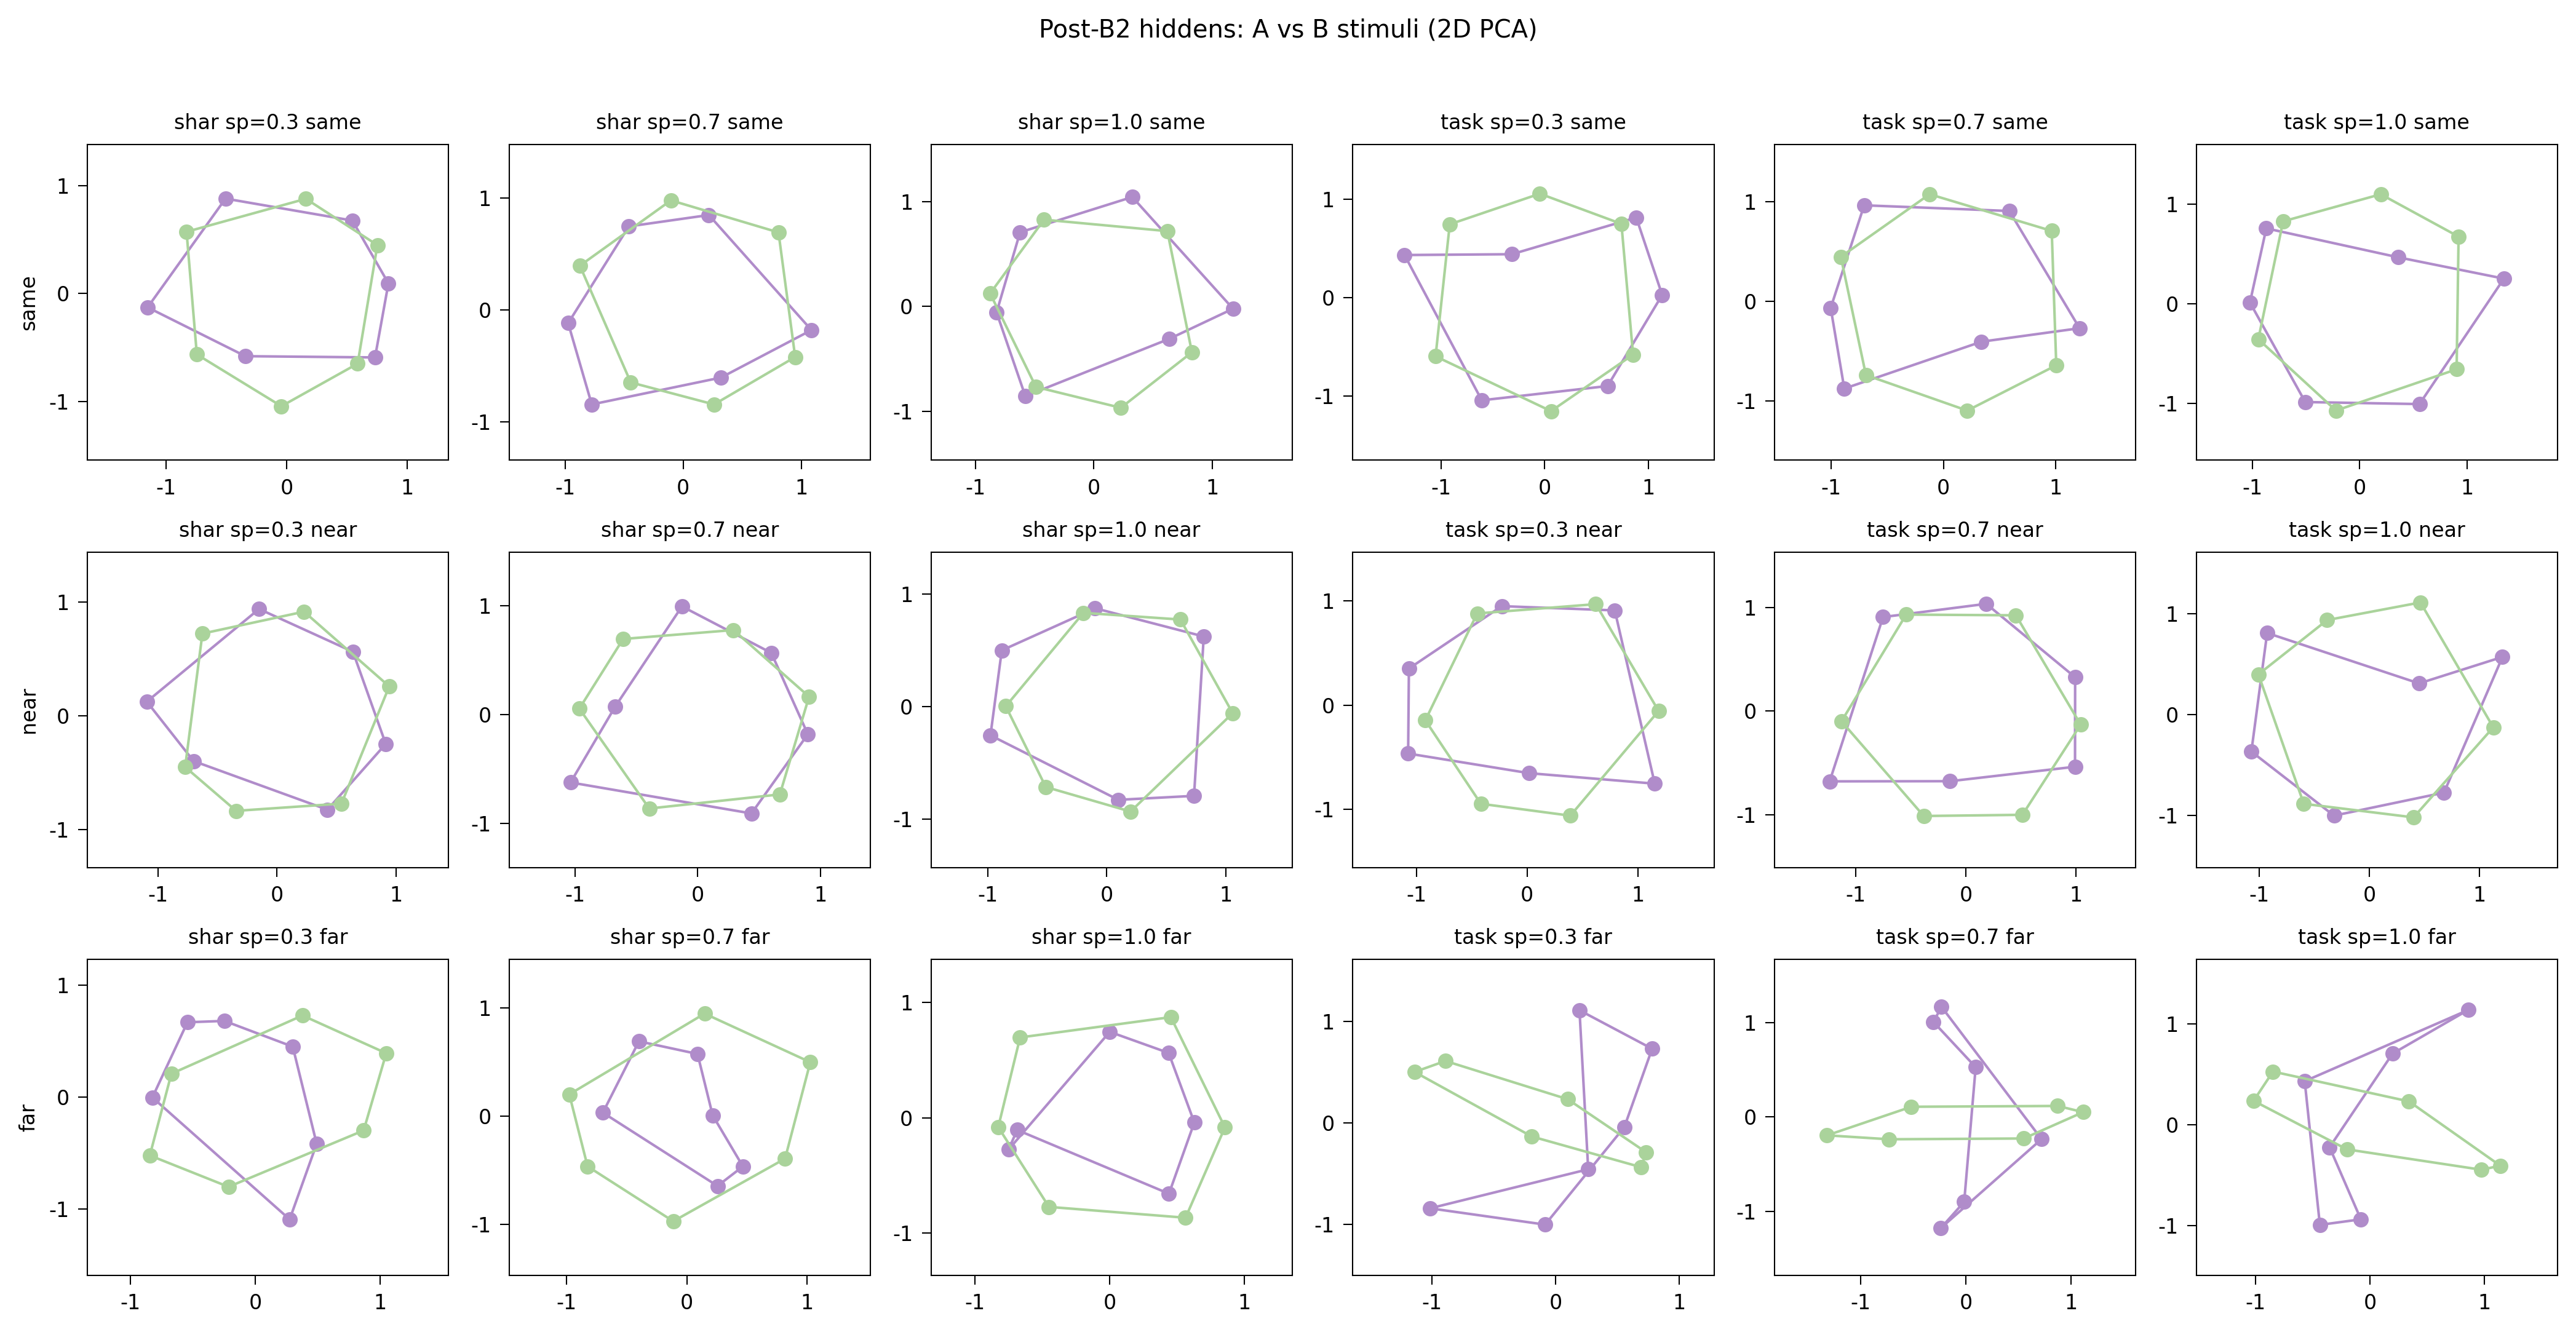

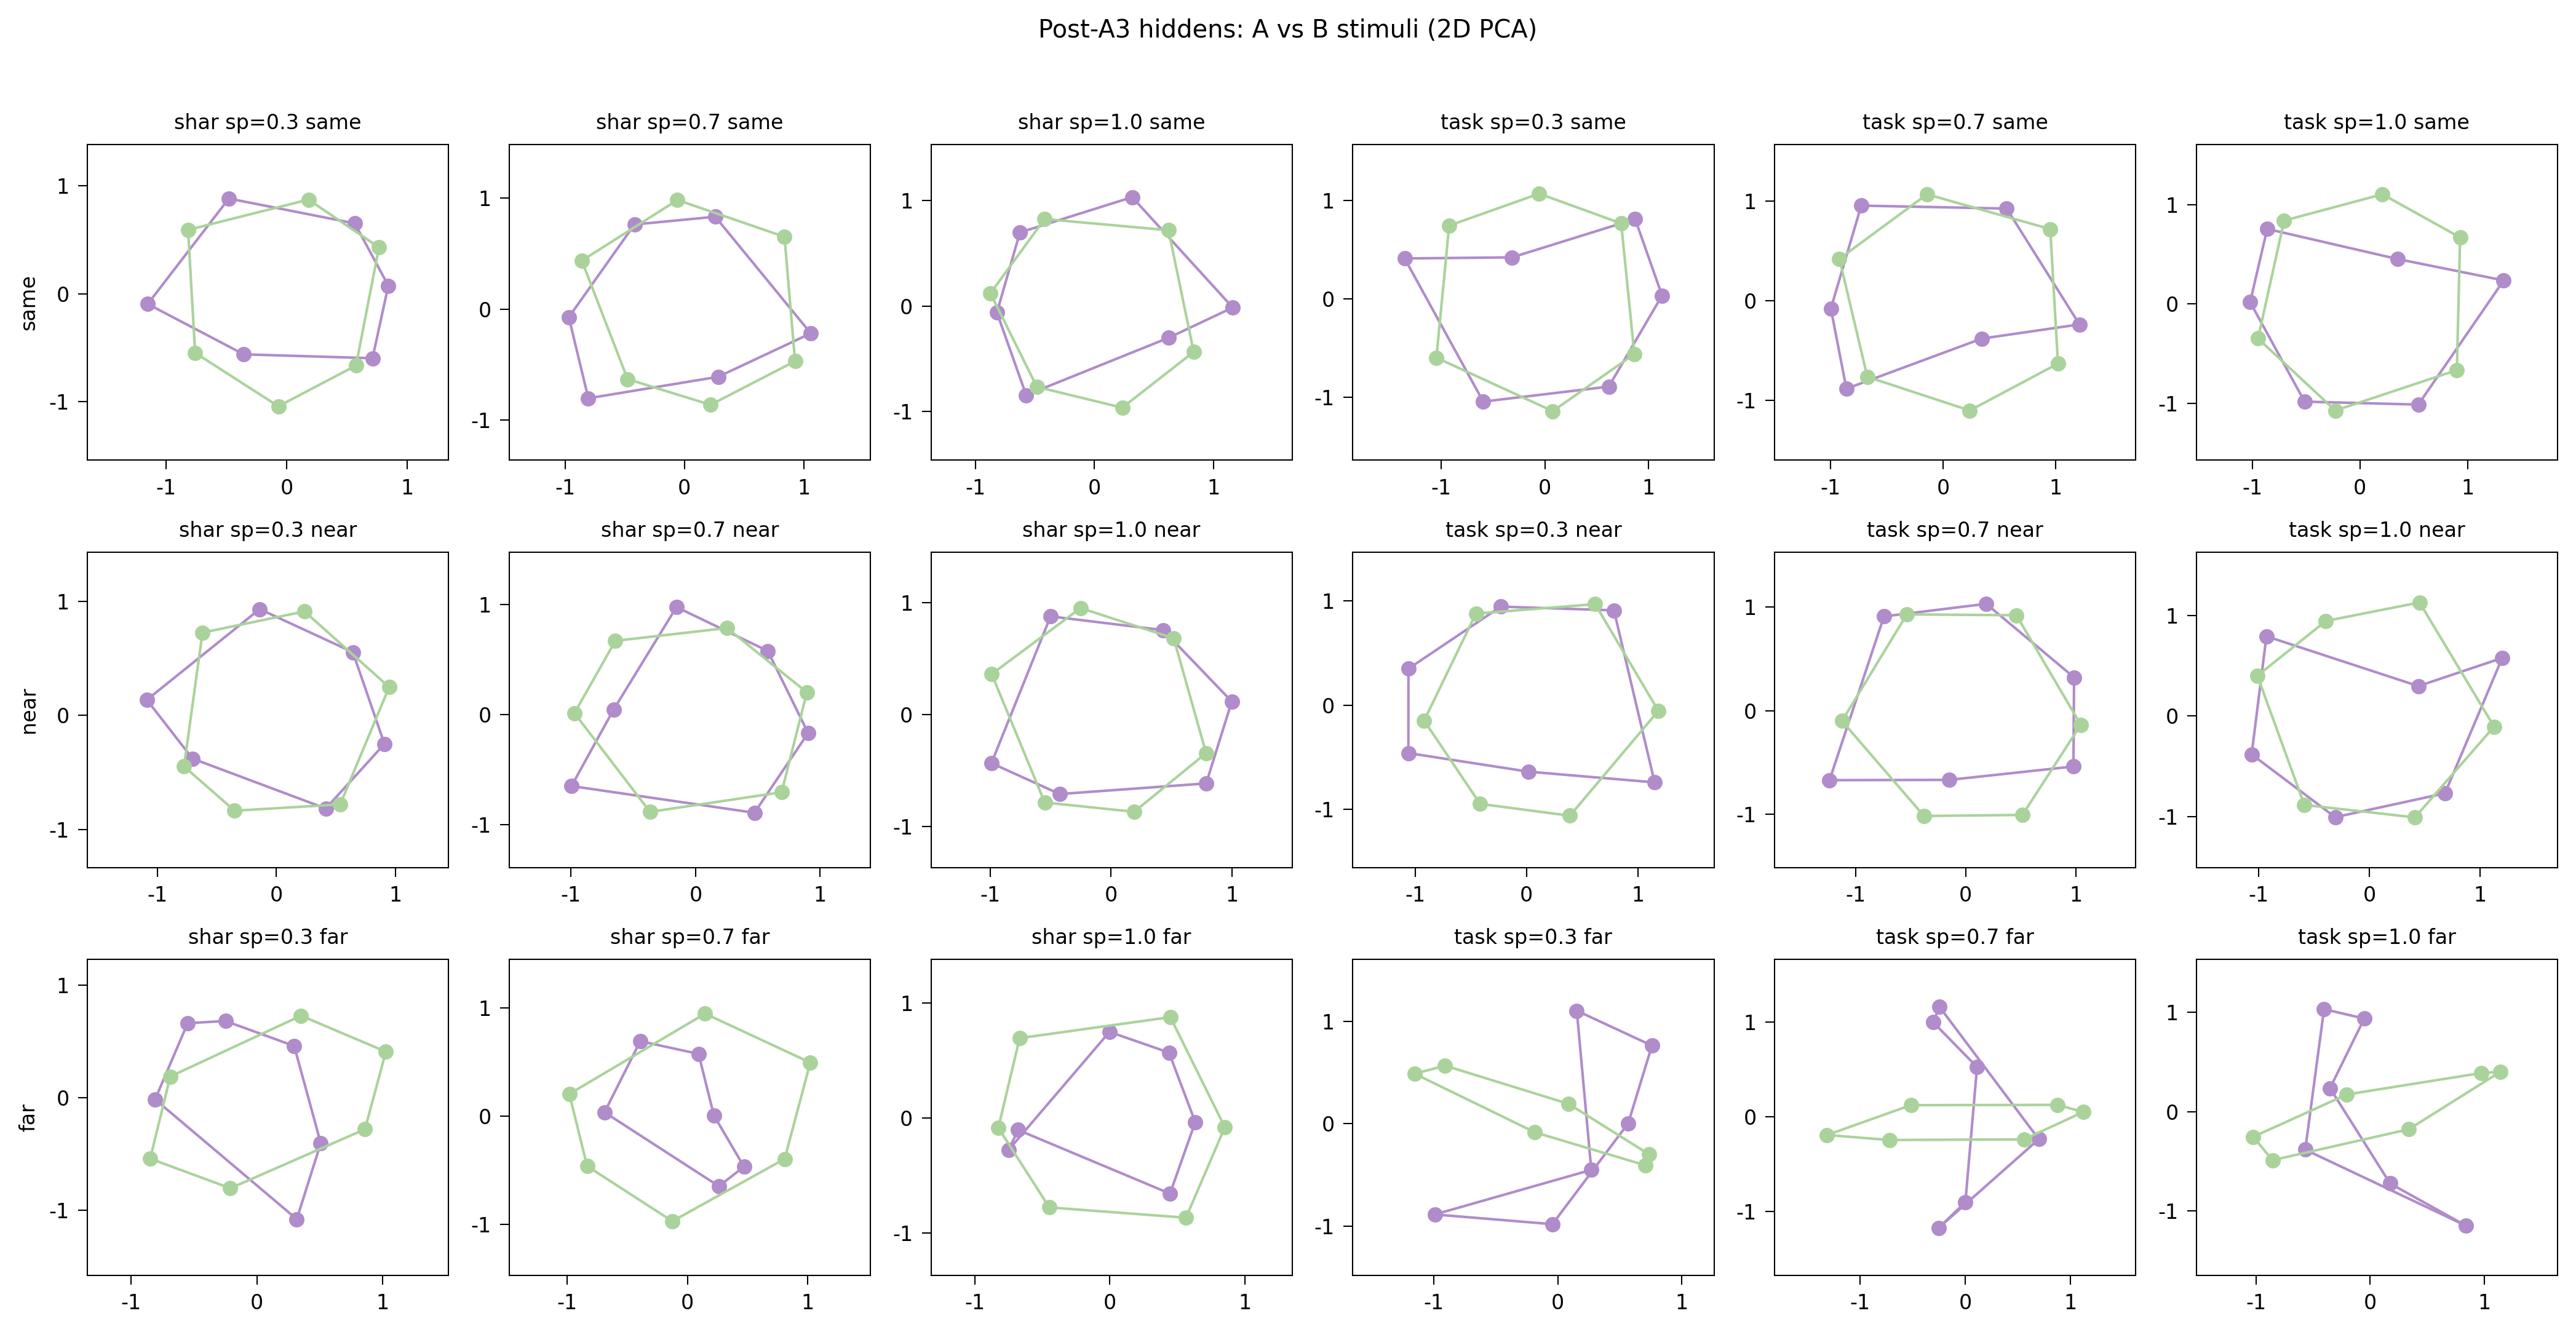

In [19]:
from a1b2.utils.figure_utils import plot_split_stim, get_axis_limits
from a1b2.utils.figure_settings import task_colours

for phase_idx in range(5):
    fig, axes = plt.subplots(3, 6, figsize=(14, 7))
    for res in all_results:
        r = rules.index(res["rule"])
        c = routings.index(res["routing"]) * 3 + sparsities.index(res["sparsity"])
        ax = axes[r, c]
        h = res[f"hiddens_post_phase_{phase_idx}"]
        pca, trans = prepare_pca_single_task(h)
        lims = get_axis_limits(trans)
        plot_split_stim(ax, trans, task_colours, lims)
        ax.set_title(f"{res['routing'][:4]} sp={res['sparsity']} {res['rule']}", fontsize=8)
    fig.suptitle(f"Post-{phase_names[phase_idx]} hiddens: A vs B stimuli (2D PCA)", y=1.02)
    plt.setp(axes, xlabel="", ylabel="")
    axes[0, 0].set_ylabel("same")
    axes[1, 0].set_ylabel("near")
    axes[2, 0].set_ylabel("far")
    plt.tight_layout()
    plt.show()

- **Phase**: Accuracy and loss evolve across A1 → B1 → A2 → B2 → A3; A phases train feature 0 (summer), B phases train feature 1 (winter).
- **Task similarity (rule)**: Same/near/far control how much the B rule differs from A; far typically yields more interference and possibly larger principal angles between A and B subspaces.
- **Sparsity**: Low (0.3) vs high (0.7) vs full (1) communication between modules; lower sparsity may reduce interference or change geometry.
- **Routing**: Task_routed (A→module 1, B→module 2) vs shared input; task_routed often yields more separated representations (higher principal angles) and different accuracy/loss trajectories.